In [18]:
#Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [19]:
#Step 2: Load Dataset


df = pd.read_csv('/content/car data.csv')

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [20]:
#Step 3: Understand the Dataset

df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [21]:
#Step 4: Data Cleaning

#Remove unnecessary columns if present.

df.columns

#If dataset contains Car_Name, remove it because it may not help prediction much.

df.drop(['Car_Name'], axis=1, inplace=True)

In [22]:
#Step 5: Feature Engineering

#Convert categorical data into numerical values.


label_encoder = LabelEncoder()

df['Fuel_Type'] = label_encoder.fit_transform(df['Fuel_Type'])
df['Selling_type'] = label_encoder.fit_transform(df['Selling_type'])
df['Transmission'] = label_encoder.fit_transform(df['Transmission'])

In [23]:
#Step 6: Create New Features


df['Car_Age'] = 2026 - df['Year']

df.drop('Year', axis=1, inplace=True)

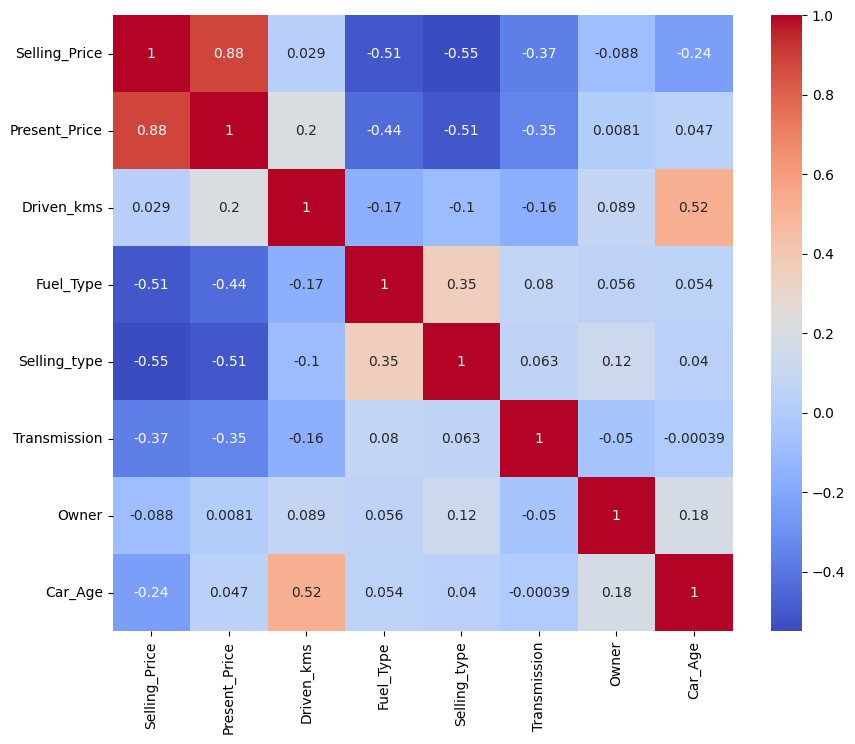

In [24]:
#Step 7: Correlation Analysis

#See feature relationships.

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [25]:
#Step 8: Define Features and Target

#Target = Selling Price

X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

In [26]:
#Step 9: Train-Test Split

#Split dataset into training and testing.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [27]:
#Step 10: Train Model

#Use Regression model.

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [28]:
#Step 11: Prediction
y_pred = model.predict(X_test)

In [29]:
#Step 12: Model Evaluation


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.6389196721311476
MSE: 0.9382767457377043
RMSE: 0.9686468632776881
R2 Score: 0.9592683769360726


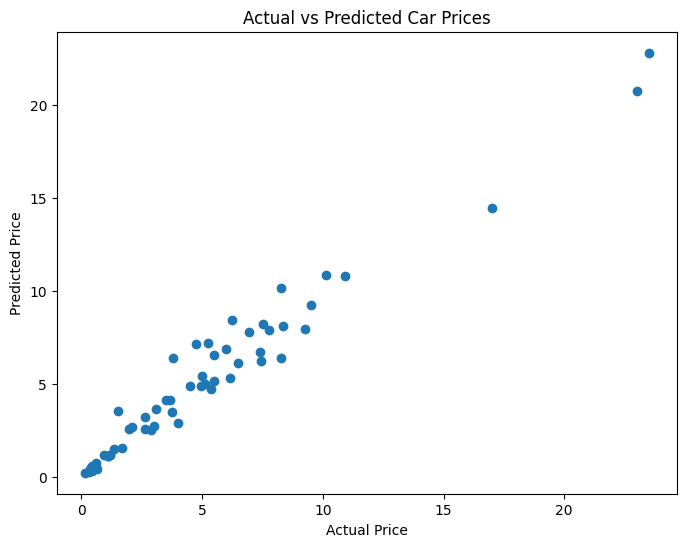

In [31]:
#Step 13: Visualization

#Compare actual vs predicted prices.

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

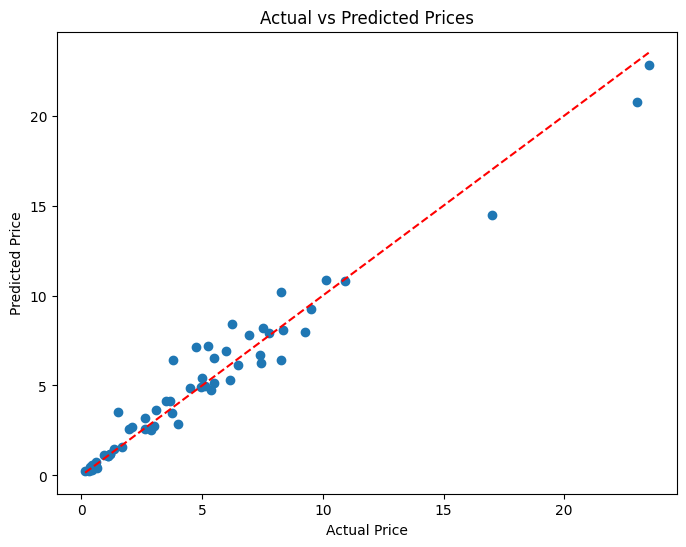

In [35]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

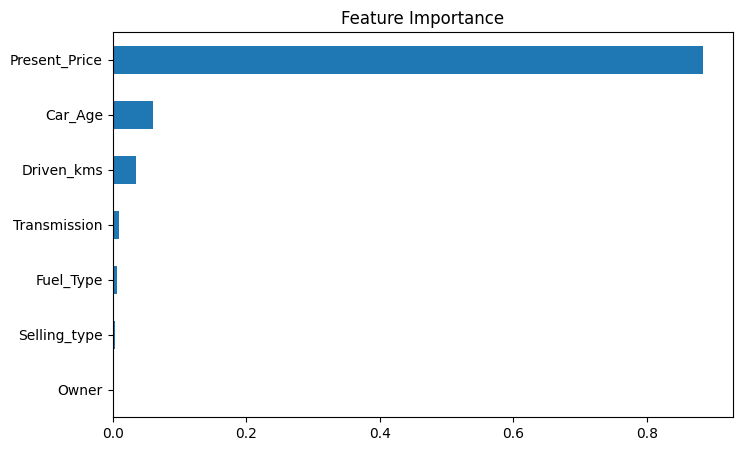

In [32]:
#Step 14: Feature Importance

#See which features matter most.

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.show()

In [36]:
#Step 15: Test Custom Input

#Predict a new car price.

sample = [[
    50.0,  # Present_Price
    30000, # Kms_Driven
    0,     # Fuel_Type
    0,     # Selling_type
    1,     # Transmission
    0,     # Owner (Assuming 0 for a new car)
    5      # Car_Age
]]

predicted_price = model.predict(sample)

print("Predicted Price:", predicted_price[0])

Predicted Price: 27.636999999999997


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
